# 04 — VDss: official benchmark-paper configuration (MFMN_InteractAux)

Reproduces this project's **current best** result for VDss against the published
benchmark (Jia et al., J. Med. Chem. 2025), using the exact protocol of
`mfmn/experiments/expv2_final_real_split.py`: fit on the **official train split only** (VD_train_test),
predict on the **official held-out test split only**, **5-seed ensemble**.

Architecture: `MFMN_InteractAux` (factorized descriptor model -- 7 mechanistic factors, each
with a privileged channel to its own named descriptors plus a shared PCA'd context, low-rank
factor interactions, per-factor auxiliary supervision weighted by `aux_weight=2.0`,
the Group-A-confirmed value for VDss). See `../src/mfmn.py` and
`../src/descriptor_features.py` for the full architecture and feature pipeline.


In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from mfmn import MFMN_InteractAux, count_params
from descriptor_features import build_shared_context, build_factor_blocks, build_aux_targets, FACTOR_NAMES
import data_loader
from metrics import eval_log_preds, bootstrap_ci, PAPER

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
TARGET = "VDss"


device: cuda


In [2]:
# ---- config: matches expv2_final_real_split.py exactly ----
AUX_WEIGHT = 2.0  # Group A confirmed value for VDss
EPOCHS, LR, WD, PATIENCE, BATCH, VAL_FRAC = 400, 3e-3, 1e-2, 50, 128, 0.15
N_SEEDS = 5
print(f"target={TARGET} model=MFMN_InteractAux aux_weight={AUX_WEIGHT} n_seeds={N_SEEDS}")


target=VDss model=MFMN_InteractAux aux_weight=2.0 n_seeds=5


In [3]:
def fit_predict(train_row_idx, test_row_idx, target, seed, verbose=False):
    all_ids, y_all, sub = data_loader.load_full_pool(target)
    row_to_y = dict(zip(sub["row_idx"], y_all))
    y_train = np.array([row_to_y[i] for i in train_row_idx], dtype=np.float32)
    y_mu, y_sd = y_train.mean(), y_train.std()
    y_s = (y_train - y_mu) / y_sd

    ctx_tr, ctx_te = build_shared_context(train_row_idx, test_row_idx)
    blocks_tr, blocks_te = build_factor_blocks(train_row_idx, test_row_idx)
    factor_raw_dims = {f: blocks_tr[f].shape[1] for f in FACTOR_NAMES}

    aux_raw = build_aux_targets(train_row_idx)
    aux_mu = {f: np.nanmean(aux_raw[f]) for f in FACTOR_NAMES}
    aux_sd = {f: (np.nanstd(aux_raw[f]) or 1.0) for f in FACTOR_NAMES}
    aux_s = {f: np.where(np.isnan(aux_raw[f]), 0.0, (aux_raw[f] - aux_mu[f]) / aux_sd[f]).astype(np.float32)
             for f in FACTOR_NAMES}
    aux_mask = {f: (~np.isnan(aux_raw[f])).astype(np.float32) for f in FACTOR_NAMES}

    T = lambda a: torch.tensor(a, device=DEVICE)
    n_all = len(y_s)
    rng = np.random.RandomState(seed)
    perm0 = rng.permutation(n_all)
    n_val = max(1, int(VAL_FRAC * n_all))
    val_i, fit_i = perm0[:n_val], perm0[n_val:]

    ctx_fit, ctx_val = T(ctx_tr[fit_i]), T(ctx_tr[val_i])
    blocks_fit = {f: T(blocks_tr[f][fit_i]) for f in FACTOR_NAMES}
    blocks_val = {f: T(blocks_tr[f][val_i]) for f in FACTOR_NAMES}
    y_fit, y_val = T(y_s[fit_i]), T(y_s[val_i])
    aux_fit = {f: T(aux_s[f][fit_i]) for f in FACTOR_NAMES}
    aux_fit_mask = {f: T(aux_mask[f][fit_i]) for f in FACTOR_NAMES}

    torch.manual_seed(seed)
    model = MFMN_InteractAux(ctx_tr.shape[1], factor_raw_dims, FACTOR_NAMES, targets=[target]).to(DEVICE)
    if verbose:
        print(f"    params={count_params(model)}")
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    n_fit = len(fit_i)
    best, best_state, bad = np.inf, None, 0
    for ep in range(EPOCHS):
        model.train()
        perm = torch.randperm(n_fit, device=DEVICE)
        for st in range(0, n_fit, BATCH):
            b = perm[st:st + BATCH]
            opt.zero_grad()
            out, aux_pred = model.forward_with_aux(ctx_fit[b], {f: blocks_fit[f][b] for f in FACTOR_NAMES})
            loss = nn.functional.smooth_l1_loss(out[target], y_fit[b], beta=0.5)
            for f in FACTOR_NAMES:
                m = aux_fit_mask[f][b]
                if m.sum() > 0:
                    err = (aux_pred[f] - aux_fit[f][b]) ** 2
                    loss = loss + AUX_WEIGHT * (err * m).sum() / m.sum()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            vout = model(ctx_val, blocks_val)
            vl = nn.functional.l1_loss(vout[target], y_val).item()
        if vl < best - 1e-4:
            best, bad = vl, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    ctx_te_t = T(ctx_te)
    blocks_te_t = {f: T(blocks_te[f]) for f in FACTOR_NAMES}
    with torch.no_grad():
        pred_s = model(ctx_te_t, blocks_te_t)[target].cpu().numpy()
    return pred_s * y_sd + y_mu


In [4]:
all_ids, y_all_log, sub = data_loader.load_full_pool(TARGET)
train_ids = sub[sub["VD_train_test"] == "train"]["row_idx"].values
test_ids = sub[sub["VD_train_test"] == "test"]["row_idx"].values
y_test_log = sub[sub["VD_train_test"] == "test"]["lgVD"].values
print(f"Official split: train={len(train_ids)}  test={len(test_ids)}")


Official split: train=1287  test=177


In [5]:
preds = []
t0 = time.time()
for s in range(N_SEEDS):
    seed = 42 + s
    p = fit_predict(train_ids, test_ids, TARGET, seed=seed, verbose=(s == 0))
    preds.append(p)
    print(f"[seed {s}] done ({time.time()-t0:.0f}s elapsed)", flush=True)

pred = np.mean(np.vstack(preds), axis=0)
m = eval_log_preds(y_test_log, pred)
ci = bootstrap_ci(10 ** y_test_log, 10 ** pred)
paper = PAPER[TARGET]
print(f"\n{'='*70}\nFINAL ({N_SEEDS}-seed ensemble): {m}")
print(f"95% CI: GMFE={ci['GMFE_ci']} within_2fold={ci['within_2fold_ci']}")
print(f"paper: GMFE={paper['GMFE']} within_2fold={paper['within_2fold']}\n{'='*70}")


    params=12976


[seed 0] done (10s elapsed)


[seed 1] done (19s elapsed)


[seed 2] done (28s elapsed)


[seed 3] done (35s elapsed)


[seed 4] done (41s elapsed)



FINAL (5-seed ensemble): {'R2': 0.6406915669007218, 'MAE': 0.2489452874669677, 'RMSE': 0.33131034720038754, 'within_2fold': 0.672316384180791, 'within_3fold': 0.8531073446327684, 'within_5fold': 0.9548022598870056, 'GMFE': 1.7739659827238727}
95% CI: GMFE=(1.653701448235901, 1.9122960764116959) within_2fold=(0.6101694915254238, 0.7401129943502824)
paper: GMFE=1.88 within_2fold=0.62


In [6]:
os.makedirs("../outputs", exist_ok=True)
out_df = pd.DataFrame({"row_idx": test_ids, "y_true_log": y_test_log, "y_pred_log": pred})
out_df.to_csv(f"../outputs/04_{TARGET}_official_test_predictions.csv", index=False)

summary = pd.DataFrame([{"target": TARGET, "n_train": len(train_ids), "n_test": len(test_ids),
                         "n_seeds": N_SEEDS, "aux_weight": AUX_WEIGHT, **m,
                         "GMFE_ci_lo": ci["GMFE_ci"][0], "GMFE_ci_hi": ci["GMFE_ci"][1],
                         "paper_GMFE": paper["GMFE"], "paper_within_2fold": paper["within_2fold"]}])
summary.to_csv(f"../outputs/04_{TARGET}_official_test_summary.csv", index=False)
print(summary.T)


                           0
target                  VDss
n_train                 1287
n_test                   177
n_seeds                    5
aux_weight               2.0
R2                  0.640692
MAE                 0.248945
RMSE                 0.33131
within_2fold        0.672316
within_3fold        0.853107
within_5fold        0.954802
GMFE                1.773966
GMFE_ci_lo          1.653701
GMFE_ci_hi          1.912296
paper_GMFE              1.88
paper_within_2fold      0.62


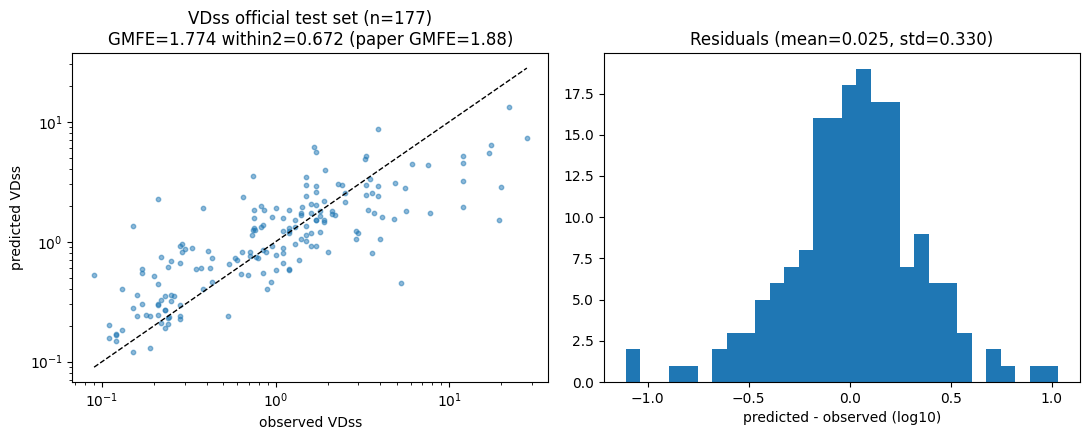

In [7]:
obs_lin, pred_lin = 10 ** y_test_log, 10 ** pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(obs_lin, pred_lin, s=10, alpha=0.5)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
lims = [min(obs_lin.min(), pred_lin.min()), max(obs_lin.max(), pred_lin.max())]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("observed " + TARGET); axes[0].set_ylabel("predicted " + TARGET)
axes[0].set_title(f"{TARGET} official test set (n={len(test_ids)})\nGMFE={m['GMFE']:.3f} within2={m['within_2fold']:.3f} (paper GMFE={paper['GMFE']})")

resid = pred - y_test_log
axes[1].hist(resid, bins=30)
axes[1].set_xlabel("predicted - observed (log10)"); axes[1].set_title(f"Residuals (mean={resid.mean():.3f}, std={resid.std():.3f})")
plt.tight_layout()
plt.savefig("../outputs/04_" + TARGET + "_official_test_plots.png", dpi=120)
plt.show()
